In [1]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

### Please check _common.py for common paths, loaded packages and functions
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Wind tower data

In [ ]:
# The wind tower data are from the Florida Coastal Monitoring Program
# The raw data are available upon request from Brian M. Phillips (brian.phillips@essie.ufl.edu)

fcmp_dir = os.path.join(data_dir, 'fcmp_tower/raw_data')
fcmp_prefix = 'Isaac_2012_T3_32Hz_'

In [3]:
### Distance from hurricane center to wind tower ###

# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')

# Interpolation function for TC track
f_loc, t0 = tc_func.get_interp_func(tc_info)

# Interpolate TC track
tlim_ = [UTCDateTime(2012,8,27,0), UTCDateTime(2012,9,1,0)]
tc_timestamp, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_range=tlim_)

# Station distance to hurricane center [km]
tc_dist = tc_func.get_station_dist(tower_loc, np.array([tc_lon, tc_lat]))

### Visualization

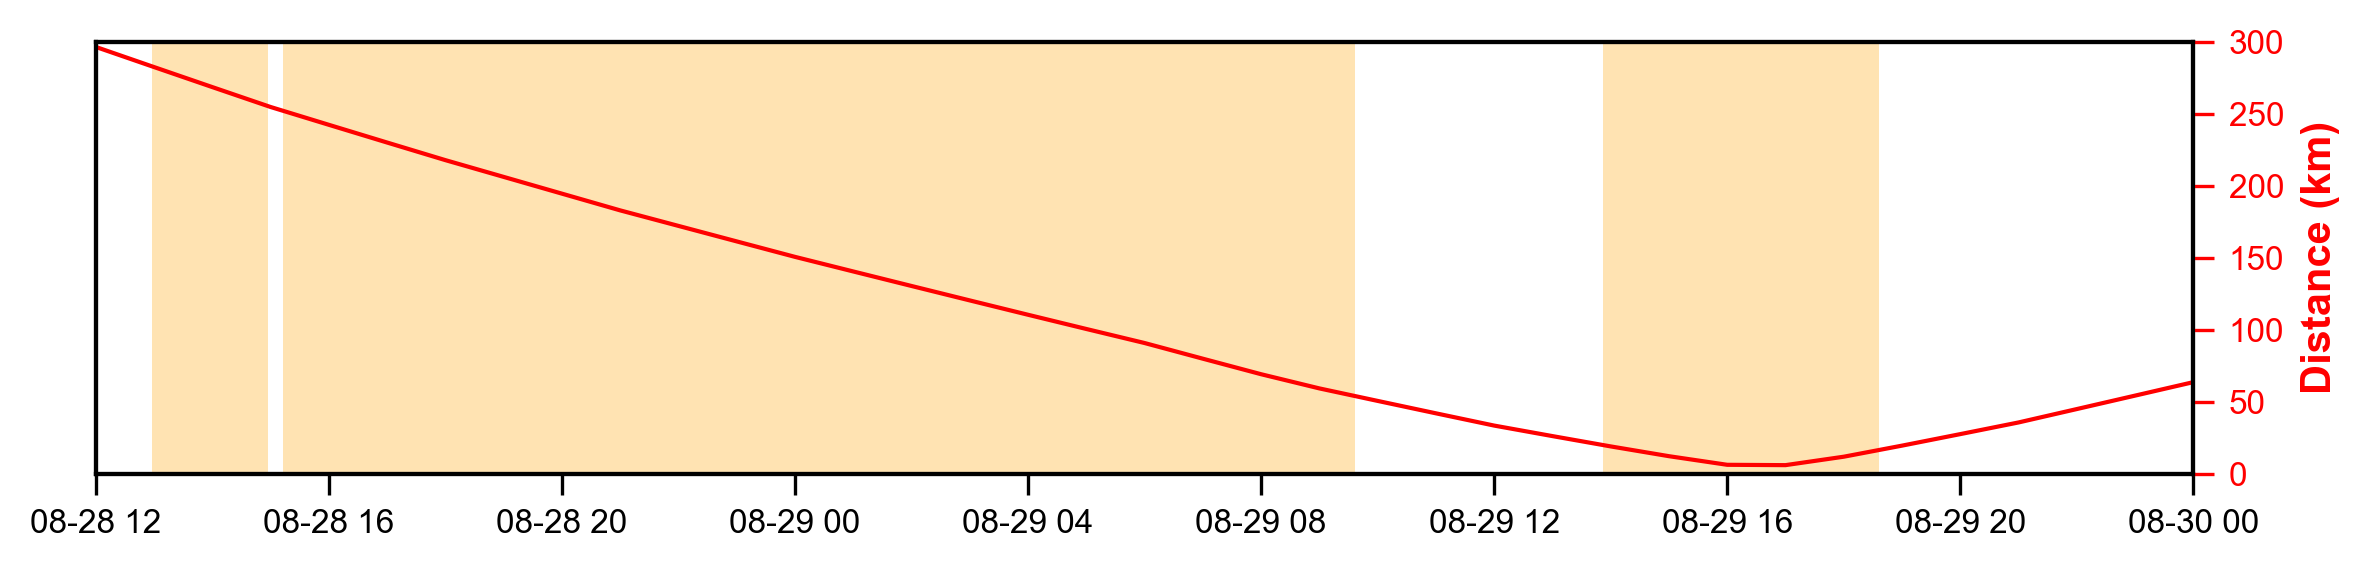

In [4]:
### Data availability ###
file_list = sorted([os.path.join(fcmp_dir, f) 
					for f in os.listdir(fcmp_dir) if f.endswith('.mat')])

fig, ax = plt.subplots(figsize=(8,2))
for i, file in enumerate(file_list):
    wind_ds = read_tower_data(file, clean_data=False, print_info=False)
    time_start = datetime.strptime(wind_ds.attrs['time_start'], "%Y-%m-%dT%H:%M:%S")
    time_end = datetime.strptime(wind_ds.attrs['time_end'], "%Y-%m-%dT%H:%M:%S")
    ax.axvspan(time_start, time_end, alpha=0.3, facecolor='orange', edgecolor=None)

ax2 = ax.twinx()
ax2.plot(tc_timestamp, tc_dist, color='r', linewidth=1)
ax2.tick_params(axis='y', colors='r')
ax2.set_ylabel('Distance (km)', color='r')
ax2.set_ylim(0, 300)
ax.set_xlim(datetime(2012,8,28,12), datetime(2012,8,30))
ax.set_yticks([])

plt.tight_layout()

### Spectrum & Structure function

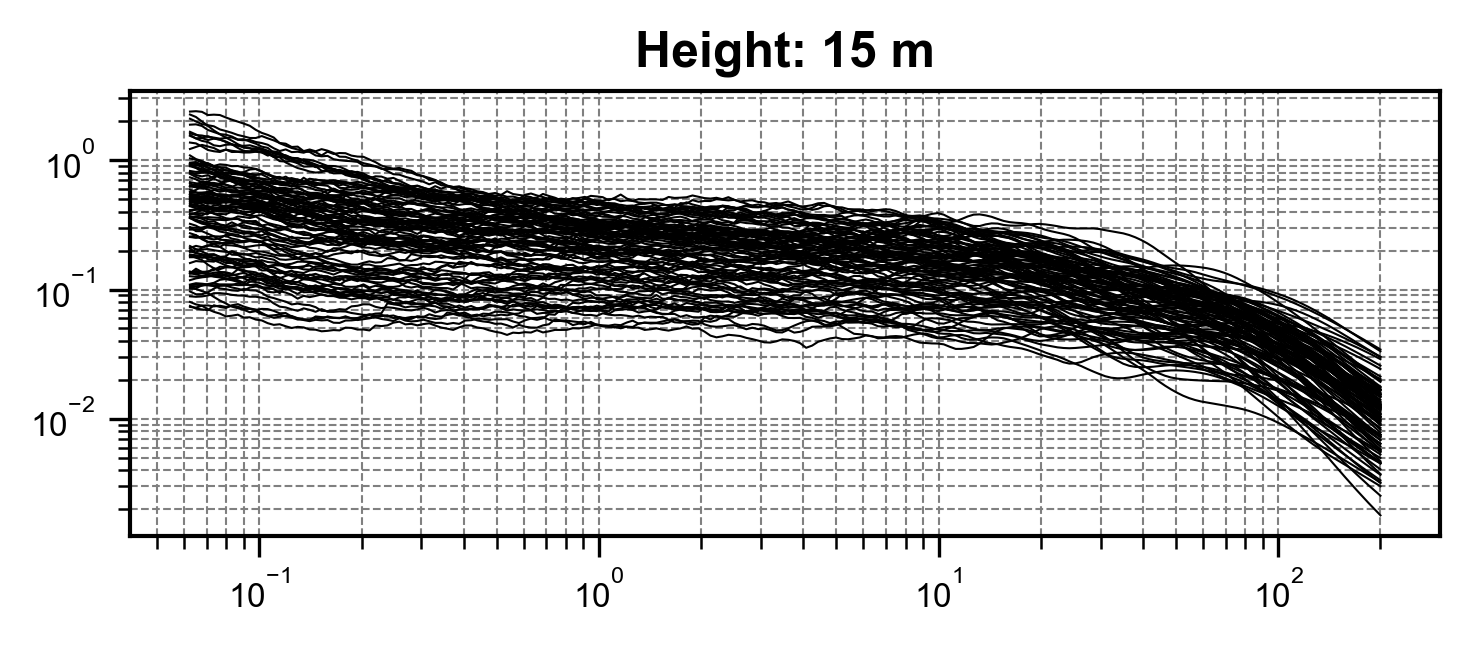

In [ ]:
### Save wind tower spectra ###

# Wind tower height to analyze (m)
sel_height = 15

# Spectral parameters
dt = 1 / 32                         # Sampling interval (s)
nperseg = 200 / dt                  # Sample points per each Welch segment
noverlap  = int(nperseg * 0.5)      # Overlap points between segments
nfreqs = 200                        # Number of frequency samples

# Smoothing parameters
if_smooth = True
smooth_mode = 'nearest'
smooth_poly = 1
smooth_npts = 20

# All wind tower data files
Nfiles = len(file_list)

# Record spectra
t_arr, U_arr = np.full(Nfiles, np.nan, dtype=object), np.full(Nfiles, np.nan)
Suu_arr, Suu_sm_arr = np.full((Nfiles, int(nperseg)//2), np.nan), np.full((Nfiles, nfreqs), np.nan)

fig, ax = plt.subplots(figsize=(5, 2.25))
for i, file in enumerate(file_list):
    wind_ds = read_tower_data(file, clean_data=True, clean_thresh=0.8, print_info=False)
    time_cur = datetime.strptime(wind_ds.attrs['time_start'], "%Y-%m-%dT%H:%M:%S")

    # Wind speed components
    if sel_height in wind_ds.coords['height'].values:
        wind_ds = wind_ds.sel(height=sel_height)
    else:
        t_arr[i] = time_cur
        continue
    
    _sin_wd = np.sin(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    _cos_wd = np.cos(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    mean_wd = np.arctan2(_sin_wd, _cos_wd)
    wind_ds['u'] =  wind_ds['ws'] * np.cos(np.deg2rad(wind_ds['wd']) - mean_wd)  # Along-wind
    
    # PSD (Welch)
    Umean = wind_ds['u'].mean().values
    up = (wind_ds['u'] - Umean).to_numpy()
    Suu, freqs = fspec.my_welch(up, dt, nperseg, noverlap, ave_method='mean')

    # Smoothing
    if if_smooth:
        freqs_ = freqs.copy()
        freqs = 10 ** np.linspace(np.log10(freqs[0]), np.log10(freqs[-1]), nfreqs)
        Suu_sm, _ = fspec.smooth_spectrum(freqs_, Suu, smooth_npts, interp=True, f_out=freqs, 
                                          smooth_mode=smooth_mode, polyorder=smooth_poly)
        
    # Store results
    t_arr[i] = time_cur
    Suu_arr[i,:] = Suu
    Suu_sm_arr[i,:] = Suu_sm
    U_arr[i] = Umean

    if Umean > 5:
        ax.loglog(1/freqs, Suu_sm*freqs**(5/3), 'k-', lw=0.5)
        # ax.loglog(1/freqs_, Suu*freqs_**(5/3), 'r-', lw=0.5)
ax.grid(which='both')
ax.set_title(f'Height: {sel_height} m')

# Save wind spectra
file_out = os.path.join(data_dir, 'fcmp_tower/turbulence', f'Suu_{sel_height}m.npz')
# np.savez(file_out, time=np.array(t_arr), freqs=freqs_, Suu=np.array(Suu_arr), 
#          freqs_sm=freqs, Suu_sm=np.array(Suu_sm_arr), U=np.array(U_arr))

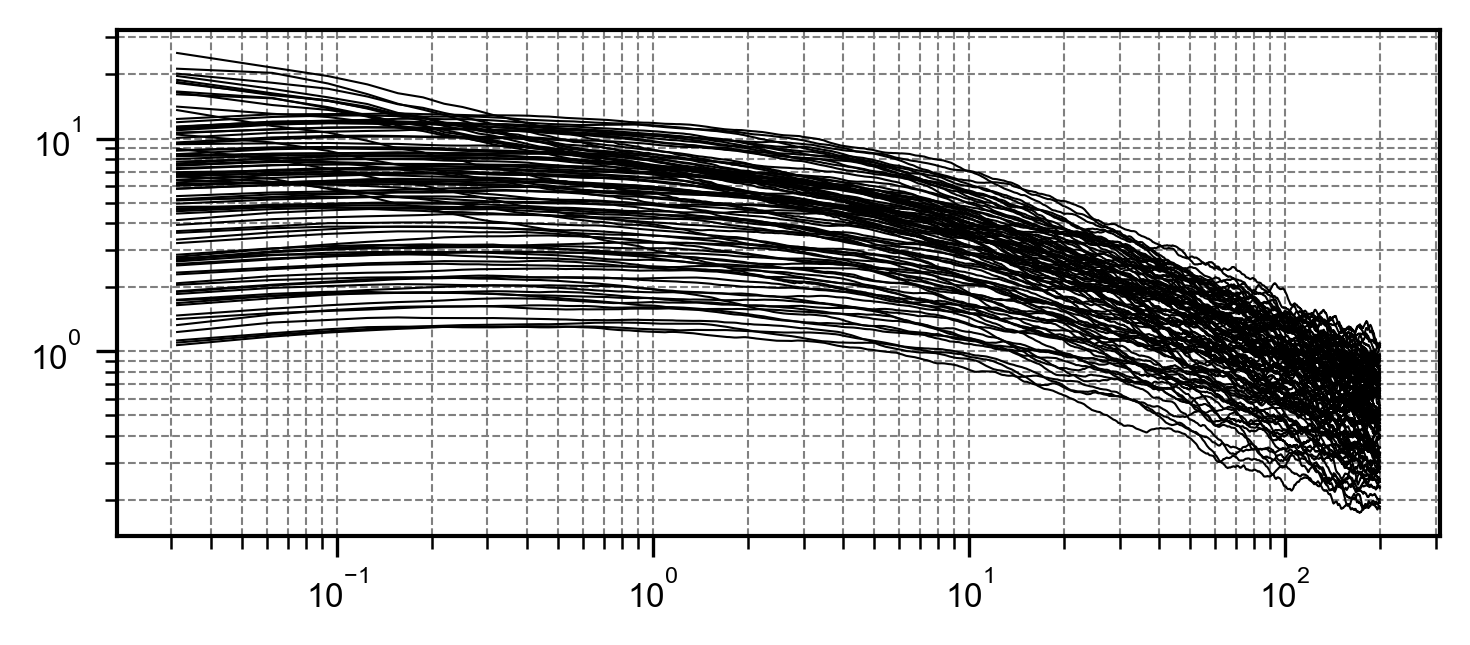

In [8]:
### Save wind tower structure function ###

# Window parameters
nperseg = 400                       # Sample length per segment (s)
noverlap  = int(nperseg * 0.5)      # Overlap between segments (s)

# Record structure function
t_arr, U_arr, Duu_arr = [], [], []

fig, ax = plt.subplots(figsize=(5, 2.25))
for i, file in enumerate(file_list):
    wind_ds = read_tower_data(file, clean_data=True, clean_thresh=0.75, print_info=False)
    time_cur = datetime.strptime(wind_ds.attrs['time_start'], "%Y-%m-%dT%H:%M:%S")

    # Wind speed components
    if sel_height in wind_ds.coords['height'].values:
        wind_ds = wind_ds.sel(height=sel_height)
    else:
        continue
    
    _sin_wd = np.sin(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    _cos_wd = np.cos(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    mean_wd = np.arctan2(_sin_wd, _cos_wd)
    wind_ds['u'] = wind_ds['ws'] * np.cos(np.deg2rad(wind_ds['wd']) - mean_wd)  # Along-wind
    wind_ds['v'] = wind_ds['ws'] * np.sin(np.deg2rad(wind_ds['wd']) - mean_wd)  # Cross-wind

    # Structure function
    Umean = wind_ds['u'].mean().values
    up = (wind_ds['u'] - Umean).to_numpy()
    D11, tau = calc_Dst(up, dt, window_length=nperseg, step=nperseg-noverlap, max_lag=None)
        
    # Store results
    t_arr.append(time_cur)
    Duu_arr.append(D11)
    U_arr.append(Umean)

    if Umean > 5:
        ax.loglog(tau, D11/tau**(2/3), 'k-', lw=0.5)

ax.grid(which='both')

# Save wind structure function
file_out = os.path.join(data_dir, 'fcmp_tower/turbulence', f'Duu_{sel_height}m.npz')
# np.savez(file_out, time=np.array(t_arr), tau=tau, Duu=np.array(Duu_arr), U=np.array(U_arr))

### Wind tower spectra at modeling time

In [25]:
# Spectral parameters
dt = 1 / 32                         # Sampling interval (s)
nperseg = 200 / dt                  # Sample points per each Welch segment
noverlap  = int(nperseg * 0.5)      # Overlap points between segments
nfreqs = 200                        # Number of frequency samples

# Smoothing parameters
if_smooth = True
smooth_mode = 'nearest'
smooth_poly = 1
smooth_npts = 20

# Wind tower data at LES modeling time
sim_file_list = sorted([os.path.join(fcmp_dir, f'{fcmp_prefix}{ind:03d}.mat') for ind in range(42, 46)])
clean_thresh = 0.05
wind_ds_sim = read_tower_data(sim_file_list, clean_data=True, clean_thresh=clean_thresh, print_info=True)

Start time: 2012-08-28 23:22:13
End time: 2012-08-29 00:22:11

NaN counts by height and variable:
5.0m: u1: 175, u2: 175, w: 175, T: 175, ws: 175, wd: 175
10.0m: u1: 7608, u2: 7608, w: 7608, T: 7608, ws: 7608, wd: 7608
15.0m: u1: 647, u2: 647, w: 647, T: 647, ws: 647, wd: 647
7.5m: u1: 115198, u2: 115198, w: 115198, T: 115198, ws: 115198, wd: 115198
12.5m: u1: 377, u2: 377, w: 377, T: 377, ws: 377, wd: 377

Excluding 10.0m: 6.60% NaNs
Excluding 7.5m: 100.00% NaNs
Height levels retained: [5.0, 15.0, 12.5]


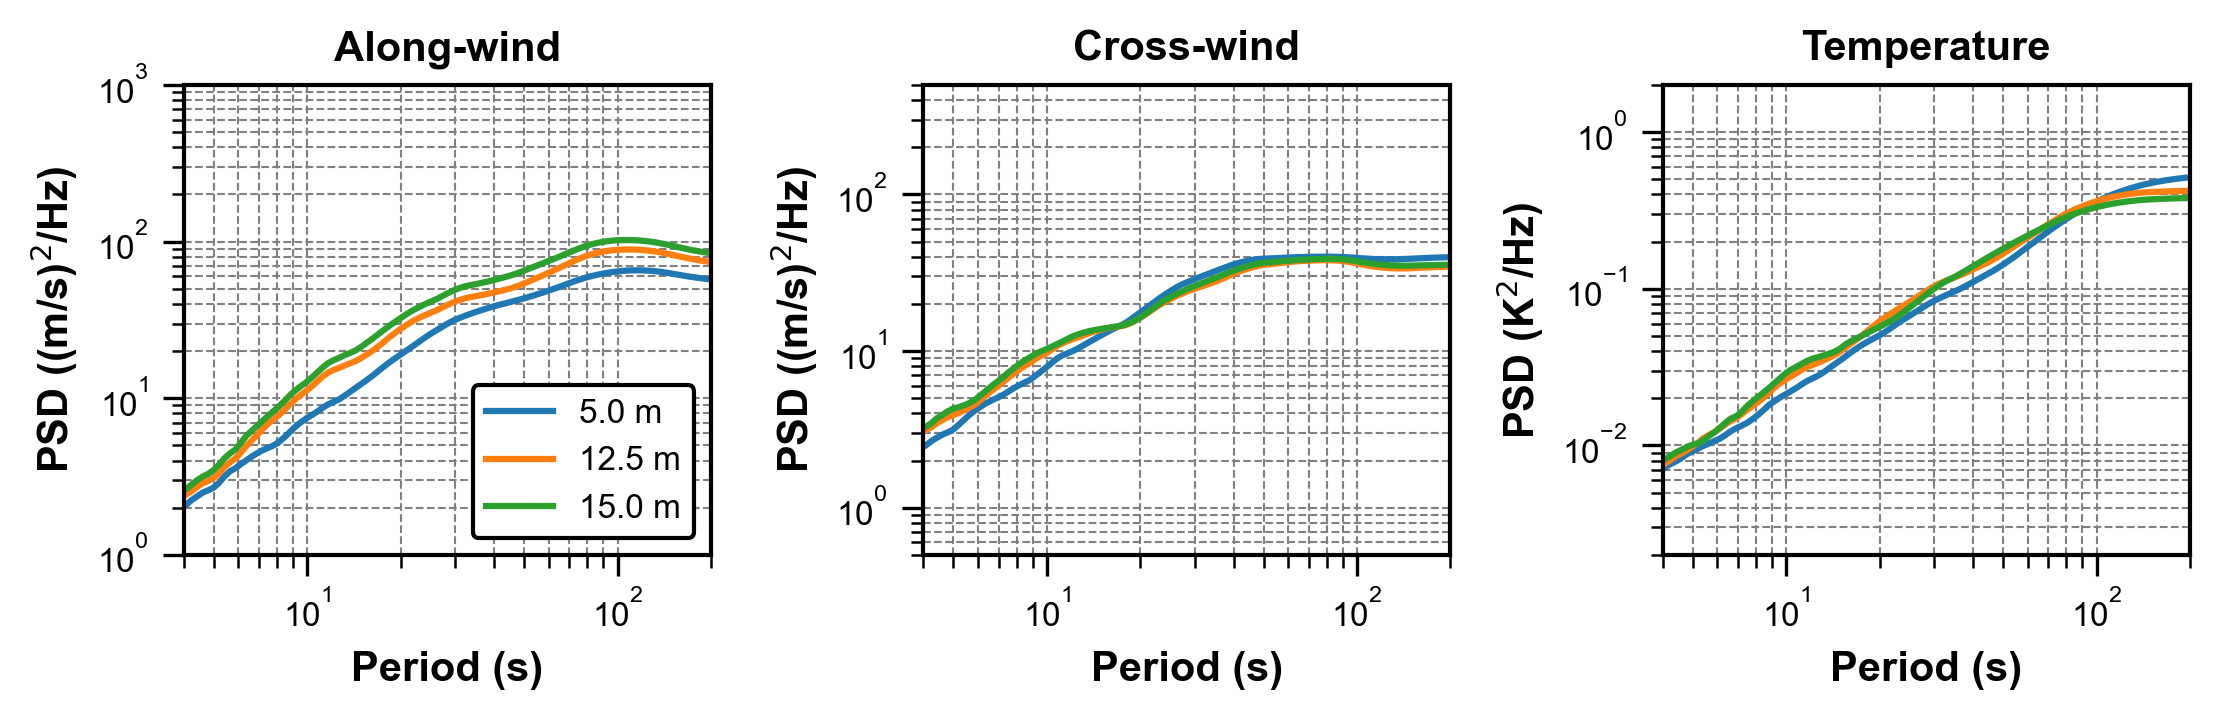

In [37]:
### Calculate wind & temperature spectra ###

# Height levels to analyze (m)
height_list = np.sort(wind_ds_sim.height.values)

# Store spectra
spec_tower = {h: {} for h in height_list}

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5), sharex=True)
for height in height_list:
    wind_ds = wind_ds_sim.sel(height=height)
    _sin_wd = np.sin(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    _cos_wd = np.cos(np.deg2rad(wind_ds['wd'])).mean(skipna=True)
    mean_wd = np.arctan2(_sin_wd, _cos_wd)
    wind_ds['u'] =  wind_ds['ws'] * np.cos(np.deg2rad(wind_ds['wd']) - mean_wd)  # Along-wind
    wind_ds['v'] = -wind_ds['ws'] * np.sin(np.deg2rad(wind_ds['wd']) - mean_wd)  # Cross-wind

    # Fluctuations
    up = (wind_ds['u'] - wind_ds['u'].mean()).to_numpy()
    vp = (wind_ds['v'] - wind_ds['v'].mean()).to_numpy()
    wp = (wind_ds['w'] - wind_ds['w'].mean()).to_numpy()
    Tp = (wind_ds['T'] - wind_ds['T'].mean()).to_numpy()

    # PSD (Welch)
    Suu, freqs = fspec.my_welch(up, dt, nperseg, noverlap, ave_method='mean')
    Svv, _ = fspec.my_welch(vp, dt, nperseg, noverlap, ave_method='mean')
    Sww, _ = fspec.my_welch(wp, dt, nperseg, noverlap, ave_method='mean')
    Stt, _ = fspec.my_welch(Tp, dt, nperseg, noverlap, ave_method='mean')

    # Smoothing 
    if if_smooth:
        freqs_ = freqs.copy()
        freqs = 10 ** np.linspace(np.log10(freqs[0]), np.log10(freqs[-1]), 200)
        Suu, _ = fspec.smooth_spectrum(freqs_, Suu, smooth_npts, interp=True, f_out=freqs, 
                                       smooth_mode=smooth_mode, polyorder=smooth_poly)
        Svv, _ = fspec.smooth_spectrum(freqs_, Svv, smooth_npts, interp=True, f_out=freqs, 
                                       smooth_mode=smooth_mode, polyorder=smooth_poly)
        Sww, _ = fspec.smooth_spectrum(freqs_, Sww, smooth_npts, interp=True, f_out=freqs, 
                                       smooth_mode=smooth_mode, polyorder=smooth_poly)
        Stt, _ = fspec.smooth_spectrum(freqs_, Stt, smooth_npts, interp=True, f_out=freqs, 
                                       smooth_mode=smooth_mode, polyorder=smooth_poly)
    
    # Plot Suu, Svv, Stt
    axes[0].loglog(1/freqs, Suu, label=f'{height} m', lw=1.5)
    axes[1].loglog(1/freqs, Svv, label=f'{height} m', lw=1.5)
    axes[2].loglog(1/freqs, Stt, label=f'{height} m', lw=1.5)

    # Store spectra
    spec_tower[height]['freqs'] = freqs
    spec_tower[height]['Suu'] = Suu
    spec_tower[height]['Svv'] = Svv
    spec_tower[height]['Sww'] = Sww
    spec_tower[height]['Stt'] = Stt
    
# Modification
axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel('PSD ((m/s)$^2$/Hz)')
axes[0].set_ylim([1e0, 1e3])
axes[0].grid(which='both')
axes[0].legend(loc='lower right', prop={'size': 8})
axes[0].set_title('Along-wind', fontsize=10)
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel('PSD ((m/s)$^2$/Hz)')
axes[1].set_ylim([5e-1, 5e2])
axes[1].grid(which='both')
axes[1].set_title('Cross-wind', fontsize=10)
axes[2].set_xlabel('Period (s)')
axes[2].set_ylabel('PSD (K$^2$/Hz)')
axes[2].set_xlim(1/np.flip([5e-3, 0.25]))
axes[2].set_ylim([2e-3, 2e0])
axes[2].grid(which='both')
axes[2].set_title('Temperature', fontsize=10)

plt.tight_layout()

## Seismic and infrasound data

In [42]:
### Select snapshot time ###

sta_char = ['TA', '645A']
stream = read(os.path.join(data_dir, 'TA/mseeds', f"{'_'.join(sta_char)}.mseed"))

snapshot_stream = stream.slice(starttime=UTCDateTime(2012,8,28,22,30), endtime=UTCDateTime(2012,8,29,1,30))
psd_tlim = [UTCDateTime(2012,8,28,23,30), UTCDateTime(2012,8,29,0,30)]
dt = snapshot_stream[0].stats.delta
Nt = snapshot_stream[0].stats.npts
timestamp = snapshot_stream[0].times('matplotlib')

### CWT parameters ###

fmin = 1/200        # Min. freq.
fmax = 1/(2*dt)     # Max. freq.
nfreqs = 200        # Freq. samples
w0 = 6.0            # Morlet wavelet parameter (rad/s)
sampling = 'log'    # Sampling method
smooth = False      # Smoothing
ns, nt = 3, 3.0     # Smoothing parameters

# Initialize fCWT
fcwt_obj, morlet_f = fspec.init_fcwt(w0, Nt, nthreads=4, fftw_plan='FFTW_MEASURE')

Threads:4
Calculating optimal scheme for forward FFT with N:2048
Calculating optimal scheme for backward FFT with N:2048
Optimization schemes for N: 2048 have been calculated. Next time you use fCWT it will automatically choose the right optimization scheme based on number of threads and signal length.
Threads:4
Calculating optimal scheme for forward FFT with N:4096
Calculating optimal scheme for backward FFT with N:4096
Optimization schemes for N: 4096 have been calculated. Next time you use fCWT it will automatically choose the right optimization scheme based on number of threads and signal length.
Threads:4
Calculating optimal scheme for forward FFT with N:8192
Calculating optimal scheme for backward FFT with N:8192
Optimization schemes for N: 8192 have been calculated. Next time you use fCWT it will automatically choose the right optimization scheme based on number of threads and signal length.
Threads:4
Calculating optimal scheme for forward FFT with N:16384
Calculating optimal sc

In [ ]:
### Spectral Analysis: Data (fCWT) ###
psd_P, psd_Z, _, coh_PZ, freqs, coi = fspec.my_fxwt(fcwt_obj, morlet_f, snapshot_stream[0].data, snapshot_stream[1].data,
                                                    dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                                    sampling='log', smooth=smooth, ns=ns, nt=nt)
mask_ = (freqs[:, None] < 1/coi) & (timestamp > psd_tlim[0].matplotlib_date) & \
    (timestamp < psd_tlim[1].matplotlib_date)
list_ = [psd_P, psd_Z, coh_PZ]
for i in range(len(list_)):
    list_[i] = np.ma.masked_array(list_[i], mask=mask_)
psd_P, psd_Z, coh_PZ = list_
# del mask_, list_

### Spectral Analysis: Data (Welch + Smoothing) ###
nperseg = 1024
noverlap = int(nperseg * 0.5)
snapshot_stream = snapshot_stream.slice(starttime=psd_tlim[0], endtime=psd_tlim[1])
psd_P_welch, freqs_welch = fspec.my_welch(snapshot_stream[0].data, dt, nperseg, noverlap, ave_method='mean')
psd_Z_welch, _ = fspec.my_welch(snapshot_stream[1].data, dt, nperseg, noverlap, ave_method='mean')

# Smoothing parameters
smooth_mode = 'nearest'
smooth_poly = 1
smooth_npts = 20

# Smoothing
freqs = np.linspace(np.log10(fmax), np.log10(fmin), num=nfreqs, endpoint=True)
freqs = np.power(10, freqs)
psd_P_obs, _ = fspec.smooth_spectrum(freqs_welch, psd_P_welch, smooth_npts, interp=True, f_out=freqs, 
                                     smooth_mode=smooth_mode, polyorder=smooth_poly)
psd_Z_obs, _ = fspec.smooth_spectrum(freqs_welch, psd_Z_welch, smooth_npts, interp=True, f_out=freqs, 
                                     smooth_mode=smooth_mode, polyorder=smooth_poly)
coh_obs = np.median(coh_PZ, axis=1)

# Save seismic spectra
spec_seis = {'freqs': freqs, 'psd_P': psd_P_obs, 'psd_Z': psd_Z_obs, 'coh_PZ': coh_obs}

In [ ]:
### Save observation spectra ###

# Wind tower
h_tower = np.array([5, 12.5, 15])
f_tower = spec_tower[h_tower[0]]['freqs']
Suu = np.vstack([spec_tower[h]['Suu'] for h in h_tower])
Svv = np.vstack([spec_tower[h]['Svv'] for h in h_tower])
Sww = np.vstack([spec_tower[h]['Sww'] for h in h_tower])
Stt = np.vstack([spec_tower[h]['Stt'] for h in h_tower])

# Seismic and infrasound
f_seis = spec_seis['freqs']
Spp = spec_seis['psd_P']
Szz = spec_seis['psd_Z']
coh_pz = spec_seis['coh_PZ']

# np.savez(os.path.join(data_dir, 'Isaac', 'obs_spectra.npz'), f_tower=f_tower, h_tower=h_tower, Suu=Suu, Svv=Svv, Sww=Sww, Stt=Stt,
#          f_seis=f_seis, Spp=Spp, Szz=Szz, coh_pz=coh_pz)